In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv

load_dotenv()
if os.environ['GOOGLE_API_KEY']:
    print("API key is set.")
else:
    raise ValueError("API key is not set")

API key is set.


In [3]:
from pydantic import BaseModel, Field
from typing import List
from langchain_tavily import TavilySearch
from langchain.messages import SystemMessage, HumanMessage

In [4]:
llm = ChatGoogleGenerativeAI(model = "gemini-3.5-flash-lite")

In [5]:
def get_text(content):
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        return "".join(
            block.get("text", "") if isinstance(block, dict) else str(block)
            for block in content
        )
    return str(content)

In [6]:
class Graph_schema(BaseModel):
    topic : str
    raw_results: List[str]
    summary: str
    report: str
    subquestions : List[str]

class Planner_schema(BaseModel):
    subquestions: List[str] = Field(description="3-4 list of qn required for research of the topic")


In [7]:
def planner(state: Graph_schema) -> dict:
    topic = state.topic
    message = [SystemMessage(content="create a list of queries to research for the topic"),HumanMessage(content = topic)]

    result = llm.with_structured_output(Planner_schema).invoke(message)

    return {"subquestions": result.subquestions}
    

In [8]:
from langchain_community.tools import DuckDuckGoSearchRun

def researcher(state: Graph_schema) -> dict:
    results = []
    # Initialize DuckDuckGo search tool
    search = DuckDuckGoSearchRun()
    
    for q in state.subquestions:
        results.append(search.invoke(q))

    return {"raw_results": results}

C:\Users\Pranish\AppData\Local\Temp\ipykernel_1348\459405756.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [9]:
def summarizer(state: Graph_schema) -> dict:
    topic = state.topic
    results = state.raw_results
    message = [SystemMessage(content="summarize the given list of results in short and effective way to preare a report"),HumanMessage(content=f"topic: {topic} \n results: {results}")]
    summarization = get_text(llm.invoke(message).content)
    return {"summary": summarization}

In [10]:
def writer(state:Graph_schema)-> dict:
    message =[SystemMessage(content = "create a short report on the given topic and summarized result"),HumanMessage(content=f"topic: {state.topic}\nsummary: {state.summary}")]

    report = get_text(llm.invoke(message).content)

    return{"report": report}

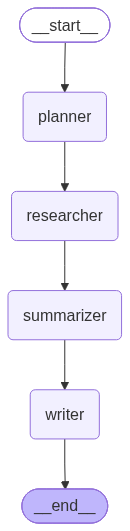

In [11]:
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image,display

graph = StateGraph(Graph_schema)

graph.add_node("planner",planner)
graph.add_node("researcher",researcher)
graph.add_node("summarizer",summarizer)
graph.add_node("writer",writer)

graph.add_edge(START,"planner")
graph.add_edge("planner","researcher")
graph.add_edge("researcher","summarizer")
graph.add_edge("summarizer","writer")
graph.add_edge("writer",END)

checkpointer = MemorySaver()
researcher_graph = graph.compile(checkpointer = checkpointer)
config={"configurable":{"thread_id": "run-1"}}

Image(researcher_graph.get_graph().draw_mermaid_png())


In [ ]:
result = researcher_graph.invoke({
    "topic": "AI",
    "subquestions": [],
    "raw_results": [],
    "report": "",
    "summary": ""
},
config=config)
print(result["report"])

# Executive Report: Artificial Intelligence (AI) Landscape

## Overview
Artificial Intelligence (AI) has transitioned from a theoretical computer science subfield into a foundational driver of 21st-century economic, social, and technological change. Powered by exponential leaps in machine learning algorithms, deep learning architectures, and specialized hardware, AI is reshaping industries at an unprecedented pace. 

This report provides a concise strategic overview of the current AI landscape, categorized by technological drivers, economic implications, governance challenges, and high-impact sector applications.

---

### Key Findings

#### 1. Technological Advancements & Capabilities
* **Core Drivers:** Modern AI progress is anchored by breakthroughs in machine learning, reinforcement learning, and advanced semiconductor chips. 
* **Strategic Focus:** Current research and development priorities have shifted toward enhancing model efficiency, reducing computational overhead, and seaml